# Store Sales Forecasting Using Historical Retail Data

**Course:** Foundations of Data Science  |  **Version 1 – Basic Baseline**

**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn

---
## 1. Problem Definition

**Problem statement:** Develop a time series forecasting model that predicts future product sales across individual retail stores using historical sales data. The model should identify temporal patterns, trends and seasonal variations in sales.

**Data source:** *Store Sales – Time Series Forecasting* (Kaggle). It contains daily sales for 54 stores of the Ecuadorian retailer *Corporación Favorita* and 33 product families, together with supporting files (stores, transactions, oil prices, holidays/events).

**Project flow:**

`Problem Definition → Data Collection → Data Cleaning → EDA → Feature Engineering → Train/Test Split → Basic Model → Evaluation → Visualization → Conclusion`

**Scope of Version 1:** keep the project simple and focused on the fundamentals – Pandas, clean data, EDA, time-based features, a time-based split and one easy-to-explain machine learning model. Advanced methods (lag features, ARIMA/Prophet, deep learning) are left for a future version.

## 2. Import Libraries

In [1]:
import os
import glob
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")          # keep the output clean
sns.set_theme(style="whitegrid")           # nicer default plot style
plt.rcParams["figure.figsize"] = (12, 5)   # default figure size
pd.set_option("display.max_columns", 50)

print("Libraries imported successfully")

Libraries imported successfully


## 3. Data Collection (Loading the Dataset)

The Kaggle download is a single `.zip` file. The next cell unzips it into a folder called `data/` (only if that has not been done already).

> **Google Colab users:** upload the zip file using the folder icon on the left, then run the notebook. It will find the zip automatically.

In [2]:
DATA_DIR = "data"

if not os.path.exists(os.path.join(DATA_DIR, "train.csv")):
    zip_files = glob.glob("*.zip")
    if len(zip_files) == 0:
        raise FileNotFoundError("Upload the dataset .zip file next to this notebook (or put the CSV files in a 'data' folder).")
    with zipfile.ZipFile(zip_files[0]) as z:
        z.extractall(DATA_DIR)
    print("Extracted", zip_files[0])

print("Files available:", sorted(os.listdir(DATA_DIR)))

Files available: ['holidays_events.csv', 'oil.csv', 'sample_submission.csv', 'stores.csv', 'test.csv', 'train.csv', 'transactions.csv']


### 3.1 Read the CSV files

| File | What it contains | Role in this project |
|---|---|---|
| `train.csv` | Daily sales for every store × product family (2013-01-01 to 2017-08-15) | **Main sales dataset** |
| `stores.csv` | City, state, store type and cluster of each store | Supporting – store information |
| `transactions.csv` | Number of customer transactions per store per day | Supporting |
| `oil.csv` | Daily oil price (Ecuador's economy depends on oil) | Supporting |
| `holidays_events.csv` | National/regional/local holidays and special events | Supporting |
| `test.csv`, `sample_submission.csv` | Competition files for the 16 days *after* the training period – **they contain no sales values** | Not used (see note below) |

> **Note:** because `test.csv` has no sales values, we cannot measure accuracy with it. Instead we create our own test set from the **last months of `train.csv`** (Section 8).

In [3]:
train        = pd.read_csv(f"{DATA_DIR}/train.csv")
stores       = pd.read_csv(f"{DATA_DIR}/stores.csv")
transactions = pd.read_csv(f"{DATA_DIR}/transactions.csv")
oil          = pd.read_csv(f"{DATA_DIR}/oil.csv")
holidays     = pd.read_csv(f"{DATA_DIR}/holidays_events.csv")

datasets = {
    "train (main sales data)": train,
    "stores": stores,
    "transactions": transactions,
    "oil": oil,
    "holidays_events": holidays,
}

for name, df in datasets.items():
    print("=" * 70)
    print(name.upper())
    print("Shape  :", df.shape)
    print("Columns:", list(df.columns))

TRAIN (MAIN SALES DATA)
Shape  : (3000888, 6)
Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']
STORES
Shape  : (54, 5)
Columns: ['store_nbr', 'city', 'state', 'type', 'cluster']
TRANSACTIONS
Shape  : (83488, 3)
Columns: ['date', 'store_nbr', 'transactions']
OIL
Shape  : (1218, 2)
Columns: ['date', 'dcoilwtico']
HOLIDAYS_EVENTS
Shape  : (350, 6)
Columns: ['date', 'type', 'locale', 'locale_name', 'description', 'transferred']


### 3.2 Data types and sample records

In [4]:
for name, df in datasets.items():
    print("=" * 70)
    print(name.upper(), "- data types")
    print(df.dtypes.to_string())
    print()
    print(name.upper(), "- first 5 records")
    display(df.head())

TRAIN (MAIN SALES DATA) - data types
id               int64
date               str
store_nbr        int64
family             str
sales          float64
onpromotion      int64

TRAIN (MAIN SALES DATA) - first 5 records
STORES - data types
store_nbr    int64
city           str
state          str
type           str
cluster      int64

STORES - first 5 records
TRANSACTIONS - data types
date              str
store_nbr       int64
transactions    int64

TRANSACTIONS - first 5 records
OIL - data types
date              str
dcoilwtico    float64

OIL - first 5 records
HOLIDAYS_EVENTS - data types
date            str
type            str
locale          str
locale_name     str
description     str
transferred    bool

HOLIDAYS_EVENTS - first 5 records


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


**Observations**

* `train` is the main table: one row = one **store**, one **product family**, one **day**, with `sales` and `onpromotion` (number of items of that family on promotion).
* The `date` columns are still plain text (`object`) – we will convert them in the cleaning step.
* The supporting tables can be joined to `train` using `date`, `store_nbr`, or the store's `city`/`state`.

## 4. Data Cleaning

We will: (1) check missing values, (2) check duplicates, (3) convert dates, (4) check for invalid or inconsistent values.

### 4.1 Missing values

In [5]:
for name, df in datasets.items():
    print(name.upper())
    missing = df.isnull().sum()
    print(missing[missing > 0].to_string() if missing.sum() > 0 else "  no missing values")
    print()

TRAIN (MAIN SALES DATA)
  no missing values

STORES
  no missing values

TRANSACTIONS
  no missing values

OIL
dcoilwtico    43

HOLIDAYS_EVENTS
  no missing values



Only `oil.csv` has missing values (the oil price column). Oil prices are only published on trading days, so weekends/holidays are empty. A sensible and simple fix is to **carry the last known price forward** (forward-fill), and use the next known price for the very first day if it is empty. We will do this later when we build a full daily calendar (Section 6).

### 4.2 Duplicate records

In [6]:
print("Duplicate rows in train          :", train.duplicated().sum())
print("Duplicate (date, store, family)  :", train.duplicated(subset=["date", "store_nbr", "family"]).sum())
print("Duplicate rows in stores         :", stores.duplicated().sum())
print("Duplicate (date, store) in transactions:", transactions.duplicated(subset=["date", "store_nbr"]).sum())
print("Duplicate rows in oil            :", oil.duplicated().sum())
print("Duplicate rows in holidays_events:", holidays.duplicated().sum())
print("Dates that appear more than once in holidays_events:", holidays.duplicated(subset=["date"]).sum())

Duplicate rows in train          : 0
Duplicate (date, store, family)  : 0
Duplicate rows in stores         : 0
Duplicate (date, store) in transactions: 0
Duplicate rows in oil            : 0
Duplicate rows in holidays_events: 0
Dates that appear more than once in holidays_events: 38


There are **no duplicate records** to remove. In `holidays_events.csv` a date can appear more than once, but this is *not* an error: a day can have several holidays/events (for example a national holiday plus a local one in one city). We will handle that when creating holiday features.

### 4.3 Convert `date` columns to datetime

In [7]:
for df in [train, transactions, oil, holidays]:
    df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

print("train date type :", train["date"].dtype)
print("Date range      :", train["date"].min().date(), "to", train["date"].max().date())
print("Unique dates    :", train["date"].nunique())

train date type : datetime64[us]
Date range      : 2013-01-01 to 2017-08-15
Unique dates    : 1684


### 4.4 Check for inconsistent or invalid values

In [8]:
print("Negative sales values         :", (train["sales"] < 0).sum())
print("Negative promotion counts     :", (train["onpromotion"] < 0).sum())
print("Non-positive oil prices       :", (oil["dcoilwtico"] <= 0).sum())
print("Non-positive transactions     :", (transactions["transactions"] <= 0).sum())
print("Store IDs in train not in stores.csv:", set(train["store_nbr"]) - set(stores["store_nbr"]))
print("Number of stores / product families :", train["store_nbr"].nunique(), "/", train["family"].nunique())
print()

# Are there days missing from the calendar?
full_calendar = pd.date_range(train["date"].min(), train["date"].max(), freq="D")
missing_days = full_calendar.difference(train["date"].unique())
print("Calendar days missing from train:", [d.date() for d in missing_days])

Negative sales values         : 0
Negative promotion counts     : 0
Non-positive oil prices       : 0
Non-positive transactions     : 0
Store IDs in train not in stores.csv: set()
Number of stores / product families : 54 / 33

Calendar days missing from train: [datetime.date(2013, 12, 25), datetime.date(2014, 12, 25), datetime.date(2015, 12, 25), datetime.date(2016, 12, 25)]


All values are valid (no negative sales/promotions, all store IDs match). The only missing calendar days are **25 December** of each year – the stores are closed, so no data was recorded. We simply leave them out.

**One more check – stores that had not opened yet.** Some stores opened *after* 2013. For those, the early rows show `sales = 0` for every product, which does not mean "no demand" – the store simply did not exist yet. Keeping these rows would teach the model wrong patterns, so we remove every row *before a store's first day with sales*.

In [9]:
# First day with any sales for each store
first_sale = train[train["sales"] > 0].groupby("store_nbr")["date"].min().rename("first_sale_date")

# Stores that opened after the data started
late_stores = first_sale[first_sale > train["date"].min() + pd.Timedelta(days=7)].sort_values()
print("Stores that opened later (first sales date):")
display(late_stores.to_frame())

rows_before = len(train)
train = train.merge(first_sale, on="store_nbr", how="left")
train = train[train["date"] >= train["first_sale_date"]].drop(columns="first_sale_date")
train = train.reset_index(drop=True)

print(f"Rows before: {rows_before:,}  |  rows after: {len(train):,}  |  removed: {rows_before - len(train):,}")

Stores that opened later (first sales date):
Rows before: 3,000,888  |  rows after: 2,778,831  |  removed: 222,057


,first_sale_date
store_nbr,
36,2013-05-09
53,2014-05-29
20,2015-02-13
29,2015-03-20
21,2015-07-24
42,2015-08-21
22,2015-10-09
52,2017-04-20


**Zeros that remain are real.** After this step, zero sales are mostly genuine (a product family not sold in a store that day, or a store closed on 1 January). We keep them because they are part of real retail behaviour.

**Cleaning summary**

| Issue | Action |
|---|---|
| Missing oil prices | Forward-fill (done in Section 6) |
| Duplicates | None found |
| `date` stored as text | Converted to datetime |
| Negative / invalid values | None found |
| Rows before a store opened (all-zero sales) | Removed |
| 25 December missing every year | Left as is (stores closed) |

## 5. Exploratory Data Analysis (EDA)

EDA means looking at the data with tables and charts to understand patterns *before* modelling. We first create two helper tables:

* `daily_sales` – total sales of **all stores and families** for each date.
* `store_daily` – total sales of **each store** for each date (this is also the level we will forecast later).

In [10]:
daily_sales = train.groupby("date")["sales"].sum()

store_daily = (train.groupby(["date", "store_nbr"])
                    .agg(sales=("sales", "sum"), onpromotion=("onpromotion", "sum"))
                    .reset_index())

print("daily_sales shape :", daily_sales.shape)
print("store_daily shape :", store_daily.shape)
display(store_daily.head())

daily_sales shape : (1684,)
store_daily shape : (84207, 4)


,date,store_nbr,sales,onpromotion
0,2013-01-01,25,2511.618999,0
1,2013-01-02,1,7417.148000,0
2,2013-01-02,2,10266.718981,0
3,2013-01-02,3,24060.348000,0
4,2013-01-02,4,10200.083980,0


### 5.1 Daily, weekly and monthly sales trends

We plot total sales over time at three levels of detail. The first and last (incomplete) week/month are dropped so that they do not look like false drops.

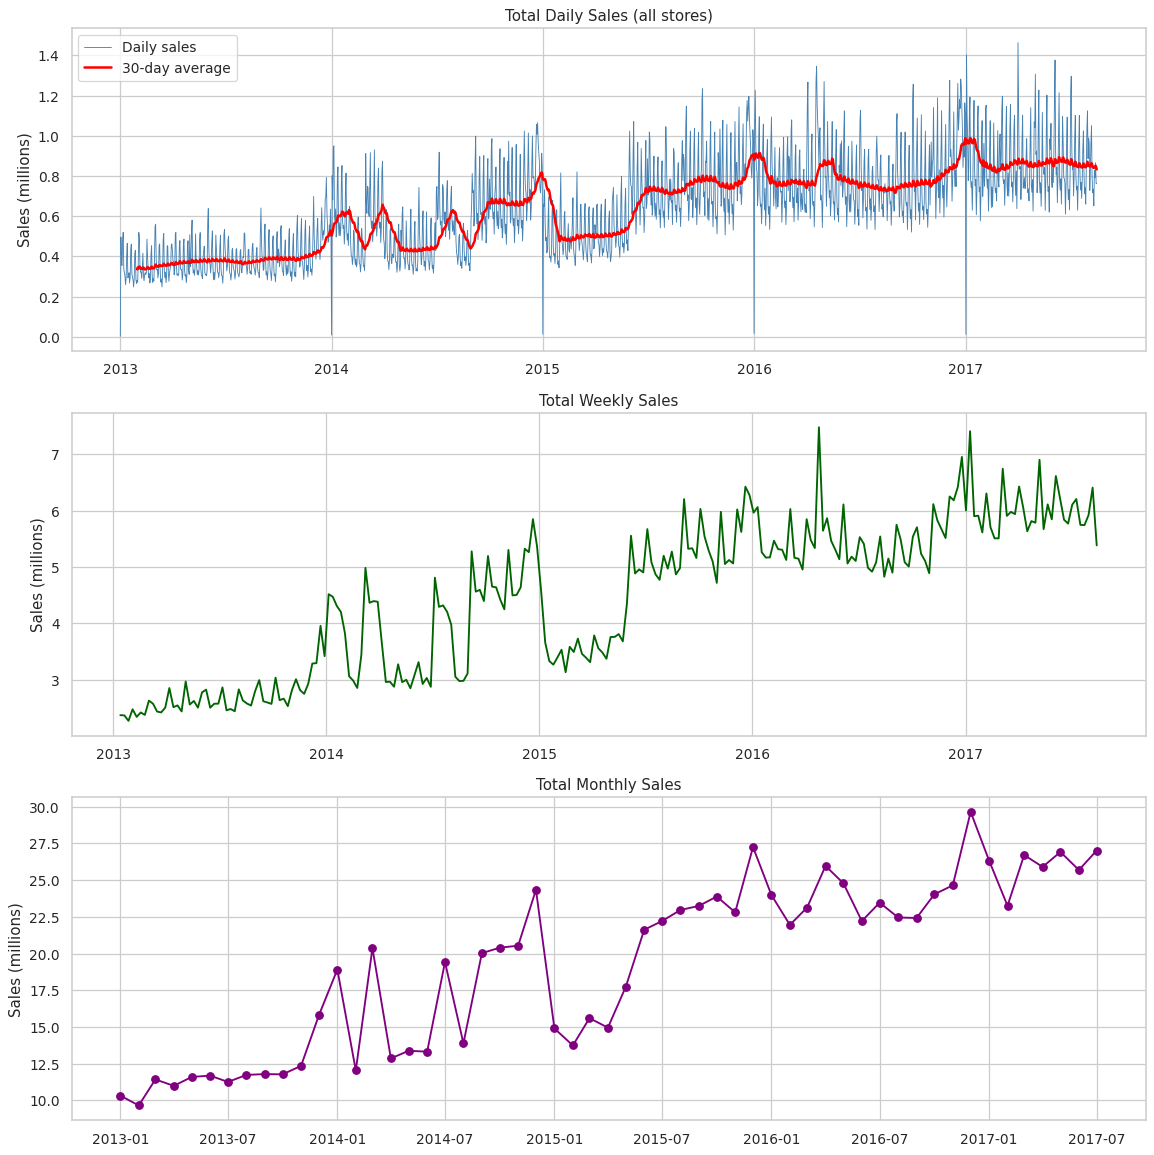

In [11]:
weekly  = daily_sales.resample("W").sum().iloc[1:-1]    # weeks end on Sunday; drop partial first/last week
monthly = daily_sales.resample("MS").sum().iloc[:-1]    # drop August 2017 (only 15 days of data)

fig, axes = plt.subplots(3, 1, figsize=(13, 13))

axes[0].plot(daily_sales.index, daily_sales.values / 1e6, color="steelblue", linewidth=0.7, label="Daily sales")
axes[0].plot(daily_sales.rolling(30).mean().index, daily_sales.rolling(30).mean().values / 1e6,
             color="red", linewidth=2, label="30-day average")
axes[0].set_title("Total Daily Sales (all stores)")
axes[0].set_ylabel("Sales (millions)")
axes[0].legend()

axes[1].plot(weekly.index, weekly.values / 1e6, color="darkgreen")
axes[1].set_title("Total Weekly Sales")
axes[1].set_ylabel("Sales (millions)")

axes[2].plot(monthly.index, monthly.values / 1e6, marker="o", color="purple")
axes[2].set_title("Total Monthly Sales")
axes[2].set_ylabel("Sales (millions)")

plt.tight_layout()
plt.show()

**What to look for:** a general upward movement over the years (trend), a repeating yearly shape (seasonality), and sharp dips on 1 January each year when most stores are closed.

### 5.2 Sales distribution

Share of product-level rows with zero sales: 25.8%

Daily sales per store (summary statistics):


,count,mean,std,min,25%,50%,75%,max
sales,84207.0,12750.1,9713.8,0.0,6405.5,9957.9,15663.0,136457.4


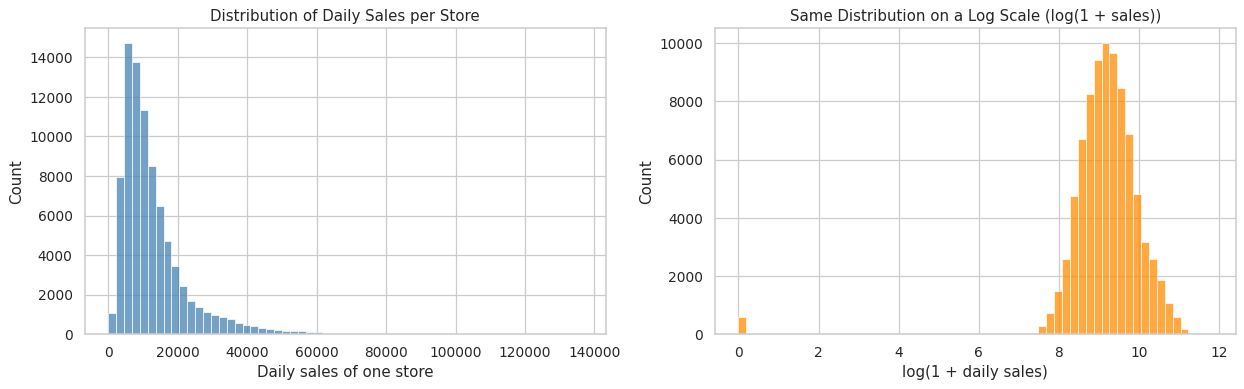

In [12]:
print("Share of product-level rows with zero sales: {:.1%}".format((train["sales"] == 0).mean()))
print()
print("Daily sales per store (summary statistics):")
display(store_daily["sales"].describe().round(1).to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(store_daily["sales"], bins=60, color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of Daily Sales per Store")
axes[0].set_xlabel("Daily sales of one store")

sns.histplot(np.log1p(store_daily["sales"]), bins=60, color="darkorange", ax=axes[1])
axes[1].set_title("Same Distribution on a Log Scale (log(1 + sales))")
axes[1].set_xlabel("log(1 + daily sales)")

plt.tight_layout()
plt.show()

The distribution is **right-skewed**: most store-days have moderate sales while a few very large stores/days create a long tail. The log scale makes the shape easier to see. The small group of values near zero are days when a store was closed.

### 5.3 Sales by store and top-performing stores

Top 10 stores by total sales:


,store_nbr,total_sales,city,state,type,cluster
0,44,6.208755e+07,Quito,Pichincha,A,5
1,45,5.449801e+07,Quito,Pichincha,A,11
2,47,5.094831e+07,Quito,Pichincha,A,14
3,3,5.048191e+07,Quito,Pichincha,D,8
4,49,4.342010e+07,Quito,Pichincha,A,11
5,46,4.189606e+07,Quito,Pichincha,A,14
6,48,3.593313e+07,Quito,Pichincha,A,14
7,51,3.291149e+07,Guayaquil,Guayas,A,17
8,8,3.049429e+07,Quito,Pichincha,D,8
9,50,2.865302e+07,Ambato,Tungurahua,A,14


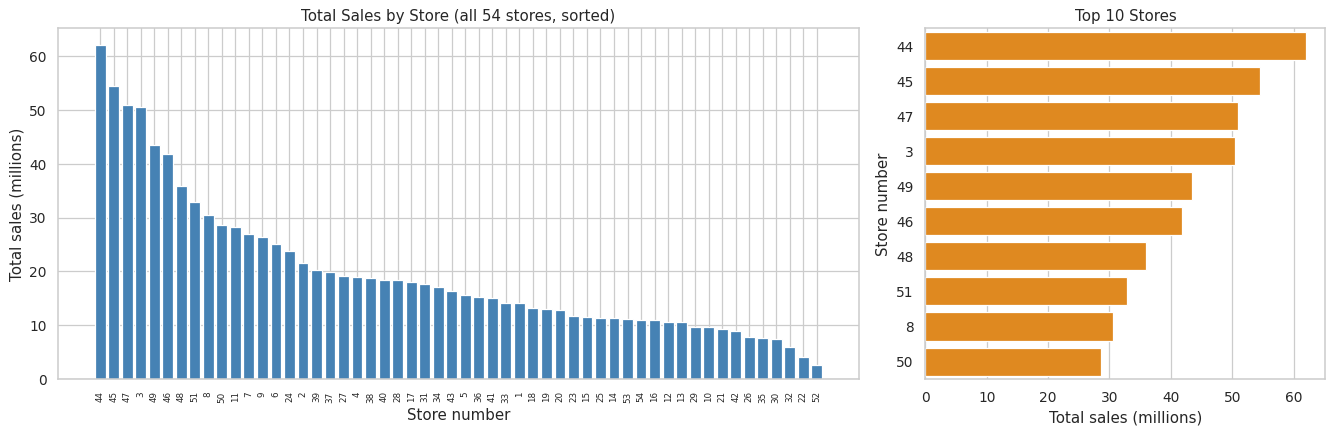

In [13]:
store_sales = train.groupby("store_nbr")["sales"].sum().sort_values(ascending=False)

top_stores = store_sales.head(10).rename("total_sales").reset_index().merge(stores, on="store_nbr")
print("Top 10 stores by total sales:")
display(top_stores)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [2, 1]})

axes[0].bar(store_sales.index.astype(str), store_sales.values / 1e6, color="steelblue")
axes[0].set_title("Total Sales by Store (all 54 stores, sorted)")
axes[0].set_xlabel("Store number")
axes[0].set_ylabel("Total sales (millions)")
axes[0].tick_params(axis="x", rotation=90, labelsize=7)

top10 = store_sales.head(10)
sns.barplot(x=top10.values / 1e6, y=top10.index.astype(str), orient="h", color="darkorange", ax=axes[1])
axes[1].set_title("Top 10 Stores")
axes[1].set_xlabel("Total sales (millions)")
axes[1].set_ylabel("Store number")

plt.tight_layout()
plt.show()

### 5.4 Sales by product family and top-selling families

Top 10 product families by total sales:


,total_sales_millions
family,
GROCERY I,343.5
BEVERAGES,217.0
PRODUCE,122.7
CLEANING,97.5
DAIRY,64.5
BREAD/BAKERY,42.1
POULTRY,31.9
MEATS,31.1
PERSONAL CARE,24.6


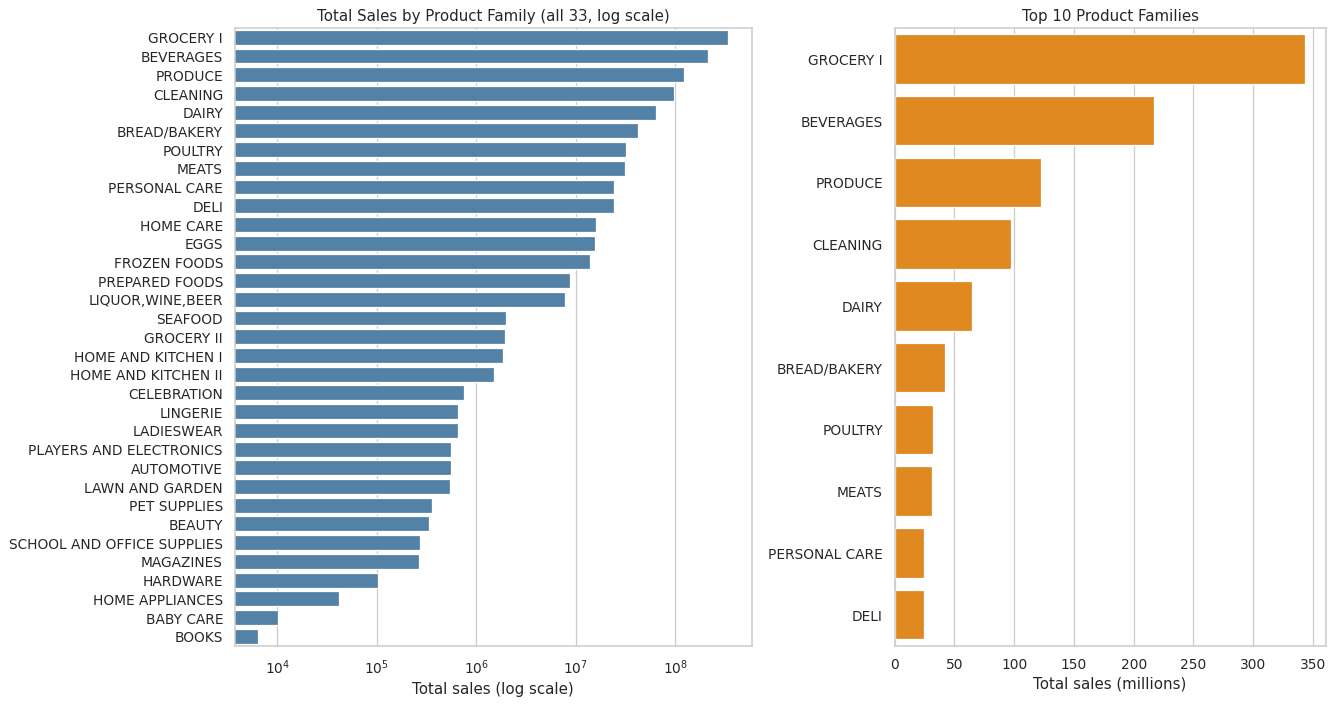

In [14]:
family_sales = train.groupby("family")["sales"].sum().sort_values(ascending=False)

print("Top 10 product families by total sales:")
display((family_sales.head(10) / 1e6).round(1).rename("total_sales_millions").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={"width_ratios": [1.2, 1]})

sns.barplot(x=family_sales.values, y=family_sales.index, orient="h", color="steelblue", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Total Sales by Product Family (all 33, log scale)")
axes[0].set_xlabel("Total sales (log scale)")
axes[0].set_ylabel("")

top10_f = family_sales.head(10)
sns.barplot(x=top10_f.values / 1e6, y=top10_f.index, orient="h", color="darkorange", ax=axes[1])
axes[1].set_title("Top 10 Product Families")
axes[1].set_xlabel("Total sales (millions)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

We also look at how the five best-selling families changed over time, and at how sales differ by **store type** (store information from `stores.csv`).

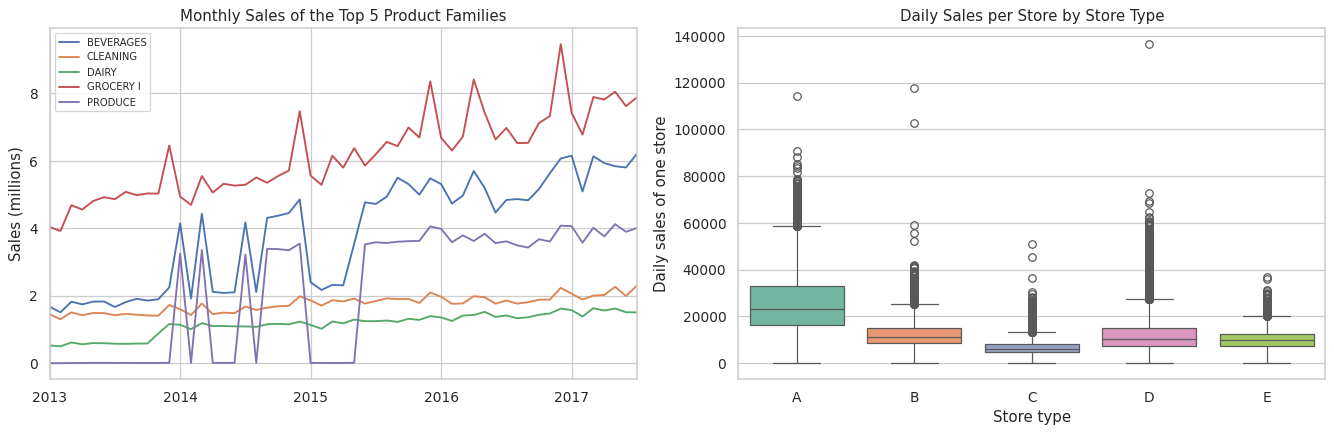

In [15]:
top5_families = family_sales.head(5).index

family_monthly = (train[train["family"].isin(top5_families)]
                  .groupby([pd.Grouper(key="date", freq="MS"), "family"])["sales"].sum()
                  .unstack().iloc[:-1])

store_daily_info = store_daily.merge(stores, on="store_nbr")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

(family_monthly / 1e6).plot(ax=axes[0])
axes[0].set_title("Monthly Sales of the Top 5 Product Families")
axes[0].set_ylabel("Sales (millions)")
axes[0].set_xlabel("")
axes[0].legend(fontsize=8)

sns.boxplot(data=store_daily_info, x="type", y="sales", order=sorted(stores["type"].unique()),
            palette="Set2", ax=axes[1])
axes[1].set_title("Daily Sales per Store by Store Type")
axes[1].set_xlabel("Store type")
axes[1].set_ylabel("Daily sales of one store")

plt.tight_layout()
plt.show()

### 5.5 Seasonality and trend

* **Weekly seasonality** – average sales for each day of the week.
* **Yearly seasonality** – average sales for each month (we use only the complete years 2013–2016 so that the incomplete year 2017 does not bias the result).
* **Trend** – a 365-day rolling average smooths out all short-term ups and downs and shows the long-term direction.

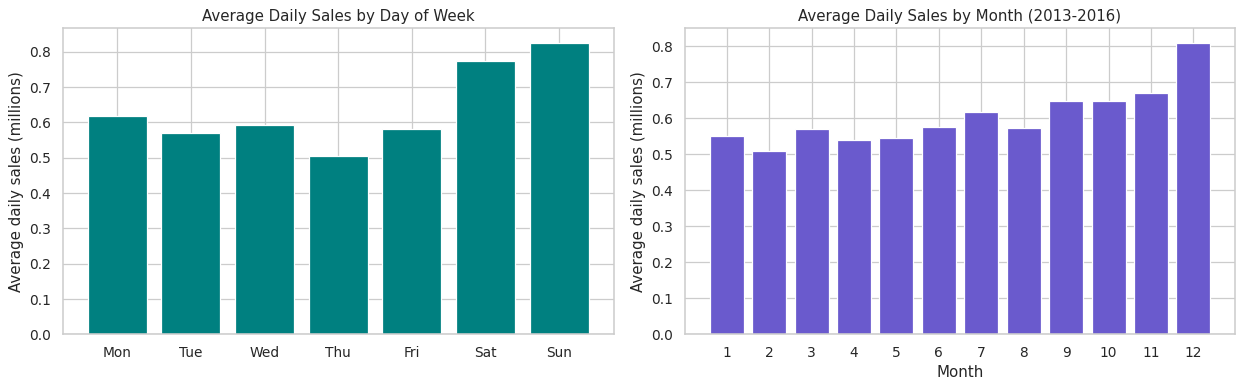

In [16]:
ds = daily_sales.to_frame("sales")
ds["year"] = ds.index.year
ds["month"] = ds.index.month
ds["day_of_week"] = ds.index.dayofweek

day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_avg = ds.groupby("day_of_week")["sales"].mean() / 1e6
month_avg = ds[ds["year"] <= 2016].groupby("month")["sales"].mean() / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(day_names, dow_avg.values, color="teal")
axes[0].set_title("Average Daily Sales by Day of Week")
axes[0].set_ylabel("Average daily sales (millions)")

axes[1].bar(month_avg.index, month_avg.values, color="slateblue")
axes[1].set_xticks(range(1, 13))
axes[1].set_title("Average Daily Sales by Month (2013-2016)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average daily sales (millions)")

plt.tight_layout()
plt.show()

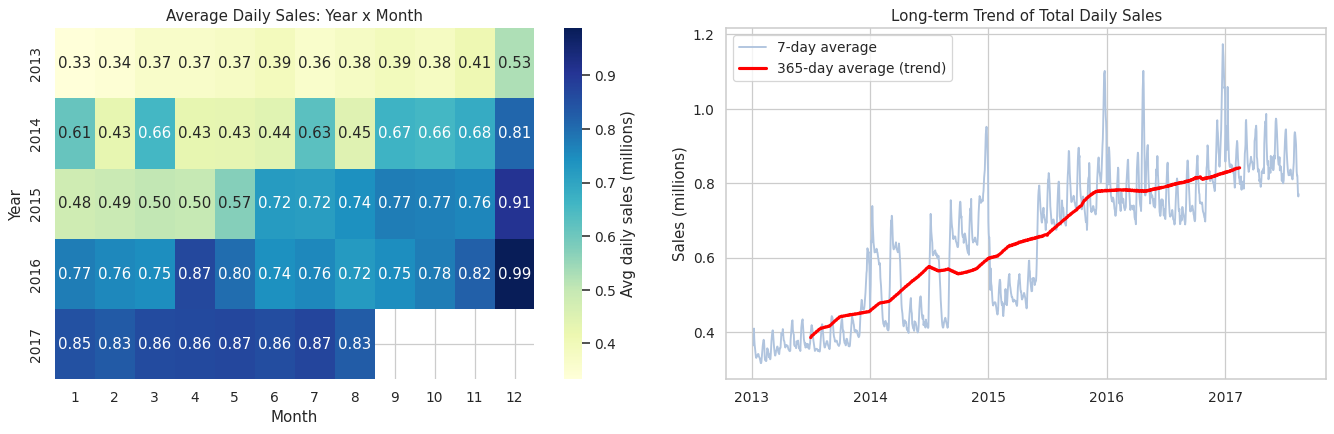

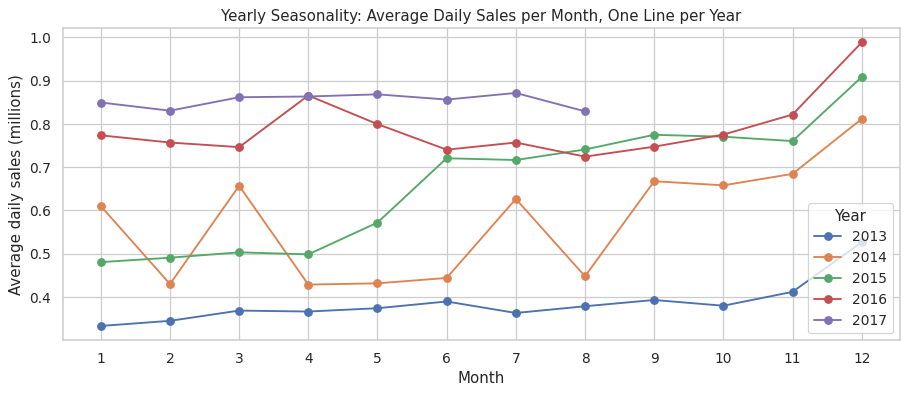

In [17]:
heat = ds.pivot_table(index="year", columns="month", values="sales", aggfunc="mean") / 1e6
trend = daily_sales.rolling(365, center=True).mean()
by_year = (ds.groupby(["year", "month"])["sales"].mean() / 1e6).unstack(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={"label": "Avg daily sales (millions)"}, ax=axes[0])
axes[0].set_title("Average Daily Sales: Year x Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Year")

axes[1].plot(daily_sales.index, daily_sales.rolling(7).mean() / 1e6, color="lightsteelblue", label="7-day average")
axes[1].plot(trend.index, trend.values / 1e6, color="red", linewidth=2.5, label="365-day average (trend)")
axes[1].set_title("Long-term Trend of Total Daily Sales")
axes[1].set_ylabel("Sales (millions)")
axes[1].legend()

plt.tight_layout()
plt.show()

by_year.plot(figsize=(12, 4.5), marker="o")
plt.title("Yearly Seasonality: Average Daily Sales per Month, One Line per Year")
plt.xlabel("Month")
plt.ylabel("Average daily sales (millions)")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.show()

**EDA takeaways** (confirmed by the charts above): sales follow a clear upward **trend**, a strong **weekly cycle** (weekends differ from weekdays), a **yearly cycle** with a peak around December, large differences between stores and product families, and occasional unusual days (1 January closures, special events). These patterns tell us which time-based features will be useful.

## 6. Feature Engineering

We now build the table that will be used for modelling. Each row = **one store on one day**. We will:

1. Create **time features** from the date.
2. Add **store information** (city, state, type, cluster).
3. Add **holiday/event** flags that apply to *that store's* location.
4. Add the **oil price** (filled for every calendar day).
5. Add **transactions** and **promotions**.

### 6.1 Time-based features

In [18]:
df = store_daily.copy()

df["year"]         = df["date"].dt.year
df["month"]        = df["date"].dt.month
df["day"]          = df["date"].dt.day
df["day_of_week"]  = df["date"].dt.dayofweek               # Monday = 0 ... Sunday = 6
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"]   = (df["day_of_week"] >= 5).astype(int)

# Extra: public-sector wages in Ecuador are paid on the 15th and the last day of the month,
# which is known to affect shopping behaviour.
df["is_payday"] = ((df["day"] == 15) | df["date"].dt.is_month_end).astype(int)

df[["date", "year", "month", "day", "day_of_week", "week_of_year", "is_weekend", "is_payday"]].head()

,date,year,month,day,day_of_week,week_of_year,is_weekend,is_payday
0,2013-01-01,2013,1,1,1,1,0,0
1,2013-01-02,2013,1,2,2,1,0,0
2,2013-01-02,2013,1,2,2,1,0,0
3,2013-01-02,2013,1,2,2,1,0,0
4,2013-01-02,2013,1,2,2,1,0,0


### 6.2 Store information, holidays/events, oil prices and transactions

**Holidays – important details**

* A holiday with `transferred = True` was *moved* to another date, so it is **not** celebrated on its original date. The moved celebration appears as a separate row with `type = "Transfer"`.
* `Work Day` rows are normal working days (made up for a bridge holiday), so they are not holidays.
* Holidays have a `locale`: **National** (applies to every store), **Regional** (applies to stores in that *state*) and **Local** (applies to stores in that *city*). We match each store with the holidays of its own location.
* `Event` rows (e.g. Mother's Day, Black Friday, the April 2016 earthquake) are kept as a separate `is_event` flag.

In [19]:
# ---- 1. Store information ----
df = df.merge(stores, on="store_nbr", how="left")

# ---- 2. Holidays and events ----
hol = holidays[(holidays["type"] != "Work Day") & (holidays["transferred"] == False)]
real_holidays = hol[hol["type"] != "Event"]
events        = hol[hol["type"] == "Event"]

national = (real_holidays[real_holidays["locale"] == "National"][["date"]]
            .drop_duplicates().assign(holiday_national=1))
regional = (real_holidays[real_holidays["locale"] == "Regional"][["date", "locale_name"]]
            .drop_duplicates().rename(columns={"locale_name": "state"}).assign(holiday_regional=1))
local    = (real_holidays[real_holidays["locale"] == "Local"][["date", "locale_name"]]
            .drop_duplicates().rename(columns={"locale_name": "city"}).assign(holiday_local=1))
event_days = events[["date"]].drop_duplicates().assign(is_event=1)

df = (df.merge(national,   on="date",            how="left")
        .merge(regional,   on=["date", "state"], how="left")
        .merge(local,      on=["date", "city"],  how="left")
        .merge(event_days, on="date",            how="left"))

flag_cols = ["holiday_national", "holiday_regional", "holiday_local", "is_event"]
df[flag_cols] = df[flag_cols].fillna(0).astype(int)
df["is_holiday"] = df[["holiday_national", "holiday_regional", "holiday_local"]].max(axis=1)

# ---- 3. Oil price: build a full daily calendar and forward-fill the gaps ----
calendar = pd.date_range(train["date"].min(), train["date"].max(), freq="D")
oil_daily = (oil.set_index("date")["dcoilwtico"].reindex(calendar)
                .ffill().bfill()                     # carry last price forward; fill the very first day backwards
                .rename("oil_price").rename_axis("date").reset_index())
df = df.merge(oil_daily, on="date", how="left")

# ---- 4. Transactions (customers per store per day) ----
df = df.merge(transactions, on=["date", "store_nbr"], how="left")

# Safety check: merging must not create or lose rows
assert len(df) == len(store_daily), "A merge changed the number of rows!"

print("Final shape:", df.shape)
print("Missing oil prices after filling:", df["oil_price"].isnull().sum())
print("Missing transactions:", df["transactions"].isnull().sum(), "(store-days with no transaction record, mostly closed days)")
df.head()

Final shape: (84207, 22)
Missing oil prices after filling: 0
Missing transactions: 719 (store-days with no transaction record, mostly closed days)


,date,store_nbr,sales,onpromotion,year,month,day,day_of_week,week_of_year,is_weekend,is_payday,city,state,type,cluster,holiday_national,holiday_regional,holiday_local,is_event,is_holiday,oil_price,transactions
0,2013-01-01,25,2511.618999,0,2013,1,1,1,1,0,0,Salinas,Santa Elena,D,1,1,0,0,0,1,93.14,770.0
1,2013-01-02,1,7417.148000,0,2013,1,2,2,1,0,0,Quito,Pichincha,D,13,0,0,0,0,0,93.14,2111.0
2,2013-01-02,2,10266.718981,0,2013,1,2,2,1,0,0,Quito,Pichincha,D,13,0,0,0,0,0,93.14,2358.0
3,2013-01-02,3,24060.348000,0,2013,1,2,2,1,0,0,Quito,Pichincha,D,8,0,0,0,0,0,93.14,3487.0
4,2013-01-02,4,10200.083980,0,2013,1,2,2,1,0,0,Quito,Pichincha,D,9,0,0,0,0,0,93.14,1922.0


### 6.3 Do these features relate to sales?

Before modelling, we quickly check how each supporting variable relates to sales.

Average daily sales per store
  normal day          : 12,554
  holiday (store area): 15,223
  special event day   : 14,767
  weekday             : 11,465
  weekend             : 15,962
  payday              : 12,903
  non-payday          : 12,739


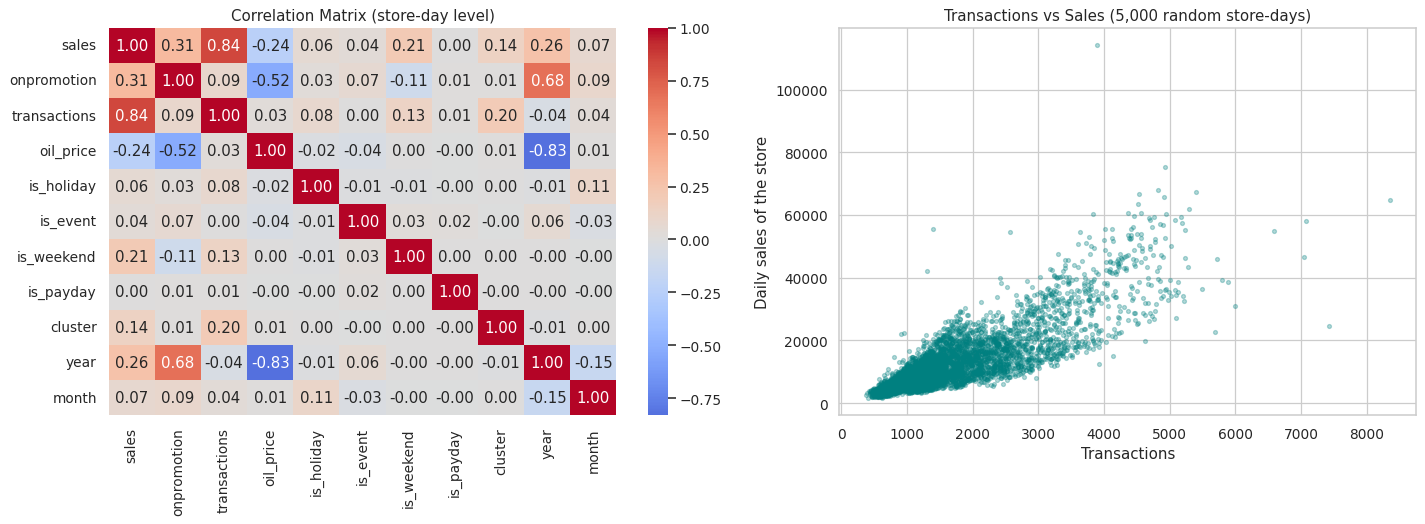

In [20]:
print("Average daily sales per store")
print("  normal day          : {:,.0f}".format(df.loc[(df["is_holiday"] == 0) & (df["is_event"] == 0), "sales"].mean()))
print("  holiday (store area): {:,.0f}".format(df.loc[df["is_holiday"] == 1, "sales"].mean()))
print("  special event day   : {:,.0f}".format(df.loc[df["is_event"] == 1, "sales"].mean()))
print("  weekday             : {:,.0f}".format(df.loc[df["is_weekend"] == 0, "sales"].mean()))
print("  weekend             : {:,.0f}".format(df.loc[df["is_weekend"] == 1, "sales"].mean()))
print("  payday              : {:,.0f}".format(df.loc[df["is_payday"] == 1, "sales"].mean()))
print("  non-payday          : {:,.0f}".format(df.loc[df["is_payday"] == 0, "sales"].mean()))

corr_cols = ["sales", "onpromotion", "transactions", "oil_price", "is_holiday", "is_event",
             "is_weekend", "is_payday", "cluster", "year", "month"]
corr = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.1, 1]})
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Correlation Matrix (store-day level)")

sample = df.dropna(subset=["transactions"]).sample(5000, random_state=42)
axes[1].scatter(sample["transactions"], sample["sales"], alpha=0.3, s=10, color="teal")
axes[1].set_title("Transactions vs Sales (5,000 random store-days)")
axes[1].set_xlabel("Transactions")
axes[1].set_ylabel("Daily sales of the store")

plt.tight_layout()
plt.show()

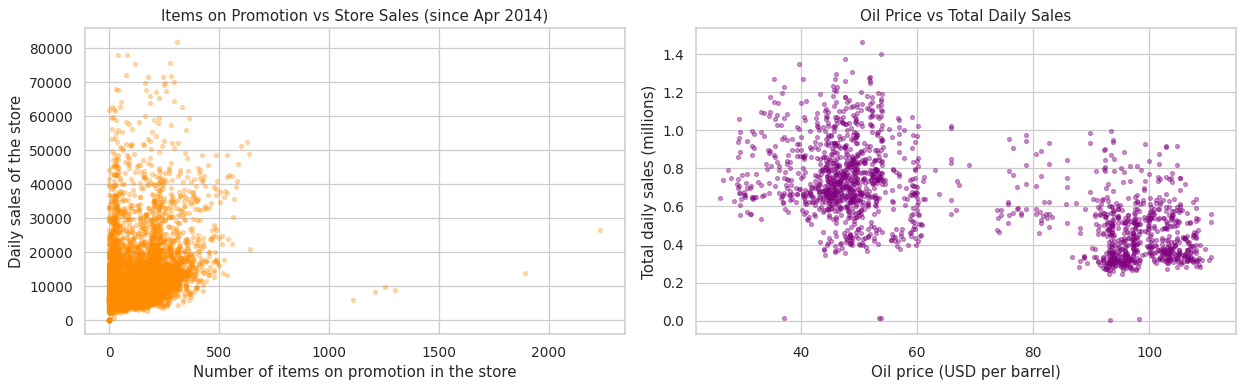

In [21]:
promo_period = df[df["date"] >= "2014-04-01"]      # promotions were not recorded before April 2014
daily_oil = df.groupby("date").agg(total_sales=("sales", "sum"), oil_price=("oil_price", "first"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].scatter(promo_period.sample(5000, random_state=42)["onpromotion"],
                promo_period.sample(5000, random_state=42)["sales"], alpha=0.3, s=10, color="darkorange")
axes[0].set_title("Items on Promotion vs Store Sales (since Apr 2014)")
axes[0].set_xlabel("Number of items on promotion in the store")
axes[0].set_ylabel("Daily sales of the store")

axes[1].scatter(daily_oil["oil_price"], daily_oil["total_sales"] / 1e6, alpha=0.4, s=10, color="purple")
axes[1].set_title("Oil Price vs Total Daily Sales")
axes[1].set_xlabel("Oil price (USD per barrel)")
axes[1].set_ylabel("Total daily sales (millions)")

plt.tight_layout()
plt.show()

**Reading the charts**

* **Transactions** have a very strong positive relationship with sales (more customers = more sales).
* **Promotions** show a positive relationship with sales. Part of this is because large stores promote more items.
* **Oil price** shows a negative relationship with total sales. Be careful: oil prices fell during the same years in which sales grew, so both are simply moving with *time*. This is correlation, not proof that oil prices cause changes in sales.
* **Weekend, payday and holiday** effects are visible in the averages printed above.

## 7. Prepare the Forecasting Dataset

### 7.1 Aggregation level
We forecast **daily total sales for each store** (one row = store × date). The original data is at store × product-family level; adding up the 33 families gives smoother, more reliable numbers for a first model and keeps the dataset small (about 90 thousand rows instead of 3 million). Product-family level forecasting is left for a future version.

### 7.2 Selecting features
A forecasting model may only use information that **would be known in advance**. This matters for `transactions`: it is the number of customers *on the same day* as the sales, so it would not be available when forecasting tomorrow (and `test.csv` does not provide it either). Using it would make the results look unrealistically good. We therefore **keep `transactions` for analysis only and do not use it as a model feature**.

| Feature group | Columns used |
|---|---|
| Store | `store_nbr`, `cluster`, store type (one-hot encoded) |
| Time | `year`, `month`, `day`, `day_of_week`, `week_of_year`, `is_weekend`, `is_payday` |
| Promotions | `onpromotion` (provided for future dates in `test.csv`) |
| Holidays/events | `is_holiday`, `is_event` |
| Oil | `oil_price` |

Store type (A–E) is text, so we convert it into 0/1 columns (**one-hot encoding**) because models need numbers.

In [22]:
type_dummies = pd.get_dummies(df["type"], prefix="type", dtype=int)
model_df = pd.concat([df, type_dummies], axis=1)

feature_cols = (["store_nbr", "cluster",
                 "year", "month", "day", "day_of_week", "week_of_year", "is_weekend", "is_payday",
                 "onpromotion", "is_holiday", "is_event", "oil_price"]
                + list(type_dummies.columns))
target_col = "sales"

print("Number of features:", len(feature_cols))
print(feature_cols)
display(model_df[feature_cols + [target_col]].head())

Number of features: 18
['store_nbr', 'cluster', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'is_weekend', 'is_payday', 'onpromotion', 'is_holiday', 'is_event', 'oil_price', 'type_A', 'type_B', 'type_C', 'type_D', 'type_E']


,store_nbr,cluster,year,month,day,day_of_week,week_of_year,is_weekend,is_payday,onpromotion,is_holiday,is_event,oil_price,type_A,type_B,type_C,type_D,type_E,sales
0,25,1,2013,1,1,1,1,0,0,0,1,0,93.14,0,0,0,1,0,2511.618999
1,1,13,2013,1,2,2,1,0,0,0,0,0,93.14,0,0,0,1,0,7417.148000
2,2,13,2013,1,2,2,1,0,0,0,0,0,93.14,0,0,0,1,0,10266.718981
3,3,8,2013,1,2,2,1,0,0,0,0,0,93.14,0,0,0,1,0,24060.348000
4,4,9,2013,1,2,2,1,0,0,0,0,0,93.14,0,0,0,1,0,10200.083980


## 8. Train / Test Split (Time-Based)

For time series we must **never split randomly**. A random split would put future days in the training set and past days in the test set, letting the model "see the future". Instead we train on the **earlier** period and test on the **most recent 90 days**, just like real forecasting.

Training period: 2013-01-01 to 2017-05-17 | 79347 rows
Testing period : 2017-05-18 to 2017-08-15 | 4860 rows


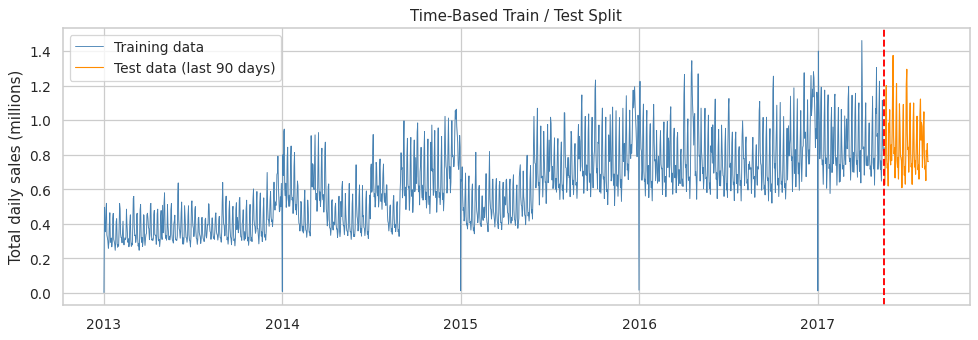

In [23]:
last_date = model_df["date"].max()
cutoff_date = last_date - pd.Timedelta(days=90)

train_set = model_df[model_df["date"] <= cutoff_date]
test_set  = model_df[model_df["date"] >  cutoff_date]

X_train, y_train = train_set[feature_cols], train_set[target_col]
X_test,  y_test  = test_set[feature_cols],  test_set[target_col]

print("Training period:", train_set["date"].min().date(), "to", train_set["date"].max().date(), "|", len(train_set), "rows")
print("Testing period :", test_set["date"].min().date(),  "to", test_set["date"].max().date(),  "|", len(test_set), "rows")

# Visualise the split
plt.figure(figsize=(13, 4))
plt.plot(daily_sales.index, daily_sales.values / 1e6, color="lightgray", linewidth=0.6)
train_total = train_set.groupby("date")["sales"].sum()
test_total  = test_set.groupby("date")["sales"].sum()
plt.plot(train_total.index, train_total.values / 1e6, color="steelblue", linewidth=0.7, label="Training data")
plt.plot(test_total.index, test_total.values / 1e6, color="darkorange", linewidth=0.9, label="Test data (last 90 days)")
plt.axvline(cutoff_date, color="red", linestyle="--")
plt.title("Time-Based Train / Test Split")
plt.ylabel("Total daily sales (millions)")
plt.legend()
plt.show()

## 9. Build a Basic Forecasting Model

### Why Random Forest?
We use a **Random Forest Regressor**, an average of many decision trees. It is a good fit for this project because:

* It can learn **non-linear patterns** (e.g. sales jump on weekends *and* in December) without us specifying the formula.
* It handles **interactions** automatically (e.g. the weekend effect is different for large and small stores).
* It needs **no feature scaling** and works well with mixed numeric/0-1 features.
* It gives **feature importances**, which help explain *which factors influence sales*.
* It is simple to understand and a standard first model in a Foundations of Data Science course.

A plain Linear Regression would struggle because store size, weekday, month and holidays interact in non-linear ways.

### A baseline for comparison
A good model must beat something simple. Our baseline predicts, for every test day, **the store's average daily sales in the training period** – i.e. it ignores weekdays, seasons, holidays and trend.

In [24]:
# ---- Baseline: each store's average daily sales in the training period ----
store_avg = train_set.groupby("store_nbr")["sales"].mean()
baseline_pred = test_set["store_nbr"].map(store_avg).fillna(y_train.mean())

# ---- Random Forest ----
rf_model = RandomForestRegressor(
    n_estimators=100,       # number of trees
    max_depth=12,           # limit tree depth to avoid over-fitting
    min_samples_leaf=5,     # each leaf must contain at least 5 rows
    random_state=42,        # reproducible results
    n_jobs=-1               # use all CPU cores
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_pred = np.clip(rf_pred, 0, None)          # sales cannot be negative

print("Model trained successfully")

Model trained successfully


## 10. Model Evaluation

We use these metrics (all calculated on the **test set**, which the model has never seen):

* **MAE** (Mean Absolute Error) – the average size of the error, in the same unit as sales. Easy to interpret.
* **RMSE** (Root Mean Squared Error) – like MAE but penalises large errors more.
* **R²** – the share of variation in sales explained by the model (1 = perfect, 0 = no better than predicting the average).
* **RMSLE** – error measured on a log scale, i.e. relative error. It is the official metric of the Kaggle competition, so it is added for reference.

In [25]:
def evaluate(y_true, y_pred):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "RMSLE": rmsle}

results = pd.DataFrame({
    "Baseline (store average)": evaluate(y_test, baseline_pred),
    "Random Forest":            evaluate(y_test, rf_pred),
}).T

display(results.round(3))

print("Average actual daily sales per store in the test period: {:,.0f}".format(y_test.mean()))
print("Random Forest MAE as a share of that average            : {:.1%}".format(results.loc["Random Forest", "MAE"] / y_test.mean()))
print("Total sales over the test period -> actual: {:,.0f} | predicted: {:,.0f} ({:+.1%})".format(
    y_test.sum(), rf_pred.sum(), rf_pred.sum() / y_test.sum() - 1))

Average actual daily sales per store in the test period: 15,842
Random Forest MAE as a share of that average            : 11.3%
Total sales over the test period -> actual: 76,991,840 | predicted: 76,089,958 (-1.2%)


,MAE,RMSE,R2,RMSLE
Baseline (store average),3856.481,6165.623,0.657,0.322
Random Forest,1797.039,2701.934,0.934,0.170


### Which features matter most?

,importance
type_A,0.3792
store_nbr,0.2142
onpromotion,0.1381
cluster,0.0619
day_of_week,0.0551
is_weekend,0.0416
type_C,0.0222
week_of_year,0.0216
year,0.0189
day,0.0152


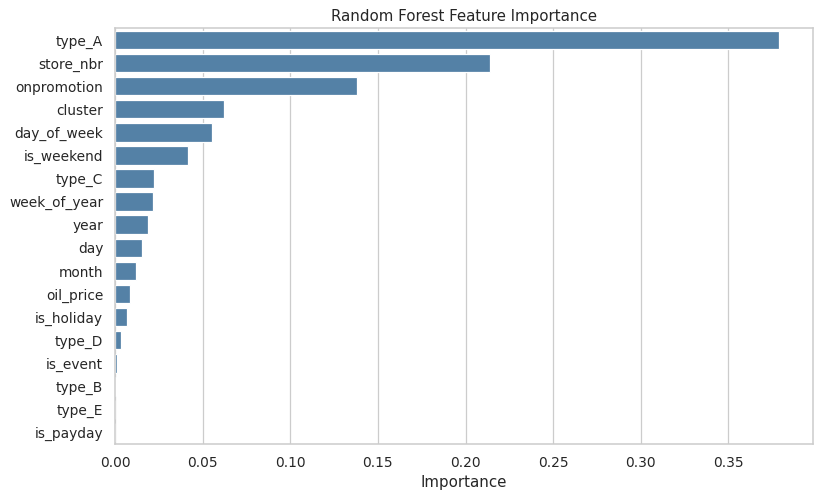

In [26]:
importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
display(importance.round(4).head(10).to_frame("importance"))

plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, orient="h", color="steelblue")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

## 11. Visualizing the Predictions

### 11.1 Actual vs predicted – all stores combined (test period)

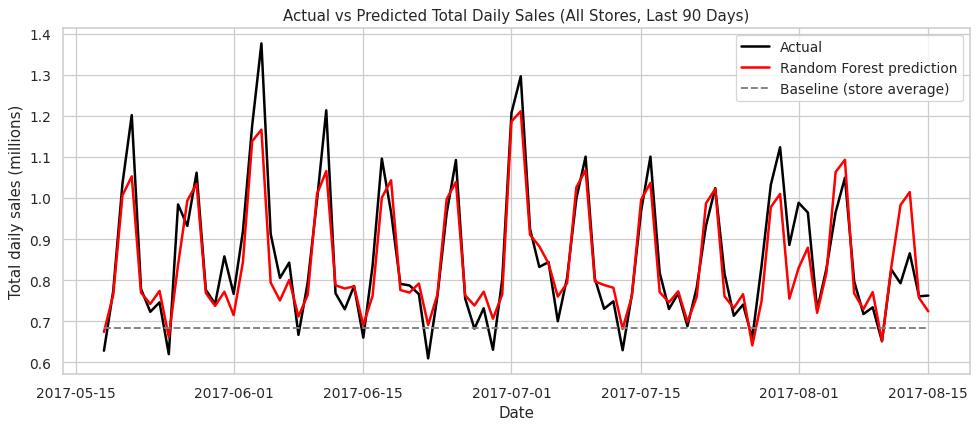

In [27]:
pred_df = test_set[["date", "store_nbr", "sales"]].copy()
pred_df["predicted"] = rf_pred
pred_df["baseline"] = baseline_pred.values

total_by_day = pred_df.groupby("date")[["sales", "predicted", "baseline"]].sum() / 1e6

plt.figure(figsize=(13, 5))
plt.plot(total_by_day.index, total_by_day["sales"], color="black", linewidth=2, label="Actual")
plt.plot(total_by_day.index, total_by_day["predicted"], color="red", linewidth=2, label="Random Forest prediction")
plt.plot(total_by_day.index, total_by_day["baseline"], color="gray", linestyle="--", label="Baseline (store average)")
plt.title("Actual vs Predicted Total Daily Sales (All Stores, Last 90 Days)")
plt.xlabel("Date")
plt.ylabel("Total daily sales (millions)")
plt.legend()
plt.show()

### 11.2 Actual vs predicted – individual stores
We pick one high-volume, one medium-volume and one lower-volume store (ranked by training-period sales).

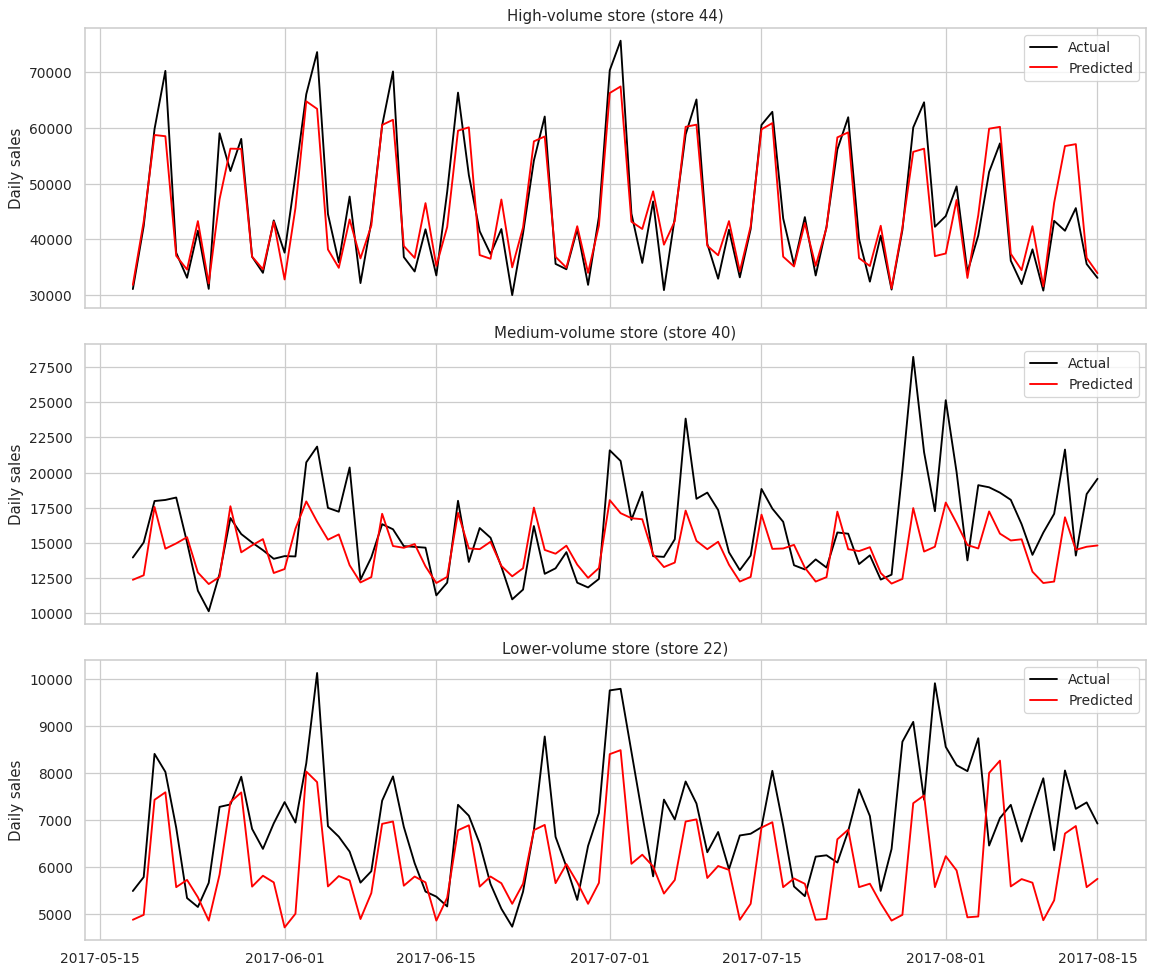

In [28]:
ranked = store_avg.sort_values(ascending=False)
chosen = [ranked.index[0], ranked.index[len(ranked) // 2], ranked.index[-6]]
labels = ["High-volume store", "Medium-volume store", "Lower-volume store"]

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
for ax, store, label in zip(axes, chosen, labels):
    one = pred_df[pred_df["store_nbr"] == store].set_index("date")
    ax.plot(one.index, one["sales"], color="black", linewidth=1.5, label="Actual")
    ax.plot(one.index, one["predicted"], color="red", linewidth=1.5, label="Predicted")
    ax.set_title(f"{label} (store {store})")
    ax.set_ylabel("Daily sales")
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 11.3 Actual vs predicted – scatter plot
If the model were perfect, every point would lie on the red diagonal line.

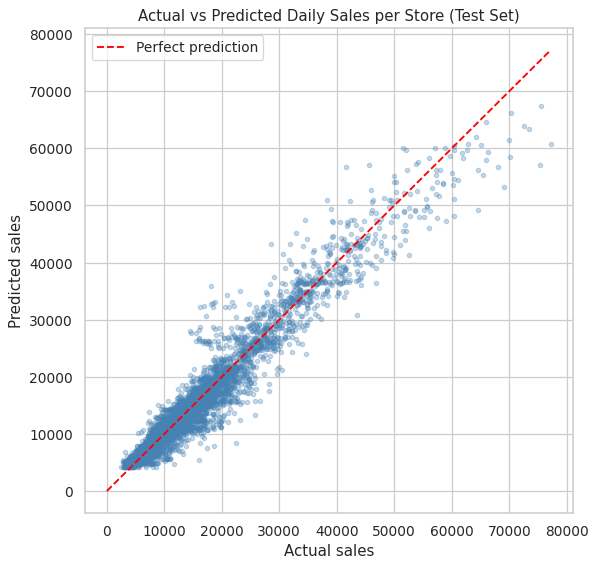

In [29]:
plt.figure(figsize=(7, 7))
plt.scatter(pred_df["sales"], pred_df["predicted"], alpha=0.3, s=12, color="steelblue")
max_val = max(pred_df["sales"].max(), pred_df["predicted"].max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect prediction")
plt.title("Actual vs Predicted Daily Sales per Store (Test Set)")
plt.xlabel("Actual sales")
plt.ylabel("Predicted sales")
plt.legend()
plt.show()

## 12. Conclusion

### What patterns were discovered?
* **Upward trend:** average total daily sales rose from about 0.39 million (2013) to about 0.86 million (2017, up to 15 August). Part of this growth comes from new stores opening and a growing promotion programme, so it is not purely "same-store" growth.
* **Weekly seasonality:** weekends are clearly stronger. The average store sells about 15,962 on a weekend day versus 11,465 on a weekday, and Saturday/Sunday are the two busiest days of the week.
* **Yearly seasonality:** December is the strongest month (about 0.81 million per day across all stores in 2013–2016, versus roughly 0.51–0.67 million in other months), with higher sales in the final quarter of the year.
* **Unusual days:** sales collapse on 1 January every year because most stores are closed. 25 December is missing from the data completely.
* **Stores and products:** sales are concentrated in a few places. Eight of the ten best stores are type A stores and eight are in Quito (store 44 is the top store). Grocery I, Beverages and Produce are the three best-selling product families.

### Which factors influenced sales?
* **Store characteristics** (type, store number, cluster) were the most important features for the Random Forest. They mainly capture store size, which is the biggest driver of how much a store sells. Together `type_A`, `store_nbr` and `cluster` account for about 65% of the total importance.
* **Promotions** (`onpromotion`, importance ≈ 0.14) were the third most important feature. The correlation with sales is positive but modest (≈ 0.26 since April 2014); note that large stores also tend to promote more items, so this is not purely a promotion effect.
* **Day of week / weekend** (`day_of_week` + `is_weekend` ≈ 0.10 combined) were the most useful time features, followed by week of year, year and month.
* **Holidays and events** are associated with higher average sales (15,223 on a holiday vs 12,554 on a normal day), but these averages are not adjusted for the upward trend, and the model gave these flags low importance (≈ 0.007 and 0.001).
* **Transactions** have a strong relationship with sales (correlation ≈ 0.84), but they are only known on the same day, so they were deliberately **not** used in the forecasting model.
* **Oil price** is negatively correlated with total sales (≈ −0.63), but this mostly reflects both series moving over time, not a proven cause. The **payday** flag had almost no effect (importance ≈ 0).

### How well did the model perform?
Evaluated on the last 90 days of data (2017-05-18 to 2017-08-15), which the model never saw during training:

| Model | MAE | RMSE | R² | RMSLE |
|---|---|---|---|---|
| Baseline (store average) | 3,856 | 6,166 | 0.657 | 0.322 |
| **Random Forest** | **1,797** | **2,702** | **0.934** | **0.170** |

* The Random Forest explains about **93%** of the variation in daily store sales (R² = 0.934).
* Its average error (MAE ≈ 1,797) is about **11% of the average daily store sales** in the test period (≈ 15,842).
* It more than halves the error of the simple baseline, so the date, store, promotion and holiday features do add real predictive value.
* Over the whole test period the model's total predicted sales were about **1.2% below** the actual total.
* Errors are larger on holidays (MAE ≈ 2,484 vs ≈ 1,777 on non-holidays) and for a store that had only just opened (store 52, which opened on 2017-04-20 and therefore had very little training history).

### Limitations of this basic model
1. **No memory of recent sales.** The model does not use lag or rolling-average features (e.g. sales 7 days ago), which are usually very powerful in forecasting.
2. **Random Forests cannot extrapolate a trend.** They can only predict values similar to those seen in training, so they can lag behind continuing growth.
3. **Store-level only.** We added up all 33 product families, so the model cannot forecast an individual product family.
4. **Some inputs are assumed known.** Promotions and oil prices are used as if known in advance; in real life, future oil prices would also need to be forecast.
5. **Simple evaluation.** One train/test split and fixed, untuned model settings were used; results may change with a different test period.
6. **Rare events are hard.** Store closures, newly opened stores and special events (e.g. the April 2016 earthquake) are poorly represented.
7. **Features not used:** city/state, `transactions`, and the product-family detail were not used as model inputs.

### How could the model be improved in the future (Version 2)?
* Add **lag and rolling features** (e.g. last week's sales, 7-day and 28-day averages) and handle the 16-day forecasting horizon properly.
* Use **time-series cross-validation** (`TimeSeriesSplit`) and **hyperparameter tuning** instead of a single split.
* Try stronger models such as **Gradient Boosting / XGBoost / LightGBM**, and compare with classical models such as **ARIMA/SARIMA** or **Prophet**.
* Forecast at the **store × product family** level, and add features such as days since a store opened, city/state and more detailed holiday information.
* Forecast the inputs that are not known in advance (such as oil price and transactions), or use their lagged values.
* Use `test.csv` to generate the official 16-day forecast and submit it to Kaggle to compare with other solutions.